# Model-4 DenseNet121

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchinfo import summary
from torchvision.models import densenet121, DenseNet121_Weights

import sys
sys.path.append("..")
from utils.metrics import evaluate_model,compare_splits

SEED = 67
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
DATA_DIR = "../dataset/processed"

TRAIN_DIR = os.path.join(DATA_DIR,"train")
VAL_DIR   = os.path.join(DATA_DIR,"val")
TEST_DIR  = os.path.join(DATA_DIR,"test")

MODEL_PATH   = "../models"
FEATURE_PATH = "../features/dense"

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-4

# Loading Data

In [3]:
transform = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),transforms.ToTensor()])

train_dataset = datasets.ImageFolder(TRAIN_DIR,transform=transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,transform=transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,transform=transform)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

NUM_CLASSES = len(train_dataset.classes)
print("Classes:",NUM_CLASSES)

Classes: 38


# Loading Model

In [4]:
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(),lr=LR)

In [5]:
summary(model,input_size=(1,3,224,224),col_names=["input_size","output_size","num_params"],depth=3)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DenseNet                                 [1, 3, 224, 224]          [1, 38]                   --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                         [1, 64, 112, 112]         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 64, 56, 56]           [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 64, 56, 56]           [1, 32, 56, 56]           (45,440)
│    │    └─_DenseLayer: 3-2             [1, 64, 56, 56]           [1, 32, 56, 56]           (49,600)
│    │    └─_De

# Model Training

In [6]:
print("\n" + "="*60)
print("\t\t    TRAINING STARTED")
print("="*60 + "\n")
total_time=0

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_metrics = evaluate_model(model,val_loader,device,show=False)
    val_acc = val_metrics["Accuracy"]
    t = time.time() - start
    total_time+=t

    print(
        f"[Epoch {epoch+1:02d}/{EPOCHS}] "
        f"Loss={avg_loss:.4f}  "
        f"ValAcc={val_acc:.4f}  "
        f"Time={t:.2f}s"
    )


print("\n Training Finished \n")
print(f"Total Time Taken : {total_time:.2f}s")
print(f"Average Time Taken per epoch : {(total_time/EPOCHS):.2f}s")


		    TRAINING STARTED

[Epoch 01/10] Loss=1.6018  ValAcc=0.9011  Time=207.94s
[Epoch 02/10] Loss=0.5327  ValAcc=0.9281  Time=218.28s
[Epoch 03/10] Loss=0.3419  ValAcc=0.9420  Time=206.73s
[Epoch 04/10] Loss=0.2613  ValAcc=0.9505  Time=209.09s
[Epoch 05/10] Loss=0.2170  ValAcc=0.9527  Time=192.47s
[Epoch 06/10] Loss=0.1873  ValAcc=0.9621  Time=190.75s
[Epoch 07/10] Loss=0.1685  ValAcc=0.9614  Time=191.05s
[Epoch 08/10] Loss=0.1531  ValAcc=0.9632  Time=190.33s
[Epoch 09/10] Loss=0.1405  ValAcc=0.9683  Time=190.55s
[Epoch 10/10] Loss=0.1318  ValAcc=0.9692  Time=190.36s

 Training Finished 

Total Time Taken : 1987.55s
Average Time Taken per epoch : 198.75s


In [7]:
model_file = os.path.join(MODEL_PATH,"densenet121.pth")
torch.save(model.state_dict(),model_file)
print("Model Saved :", model_file)

Model Saved : ../models/densenet121.pth


# Model Evaluation

TRAINING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.975596
Precision,0.975379
Recall,0.975426
F1_Score,0.975322
ROC_AUC,0.999790
Log_loss,0.102252



============================ CONFUSION MATRIX =============================


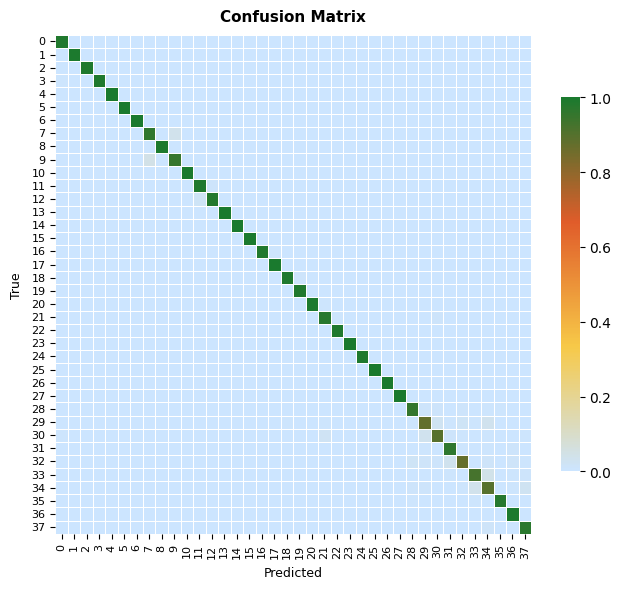


==================================== ROC CURVE ====================================


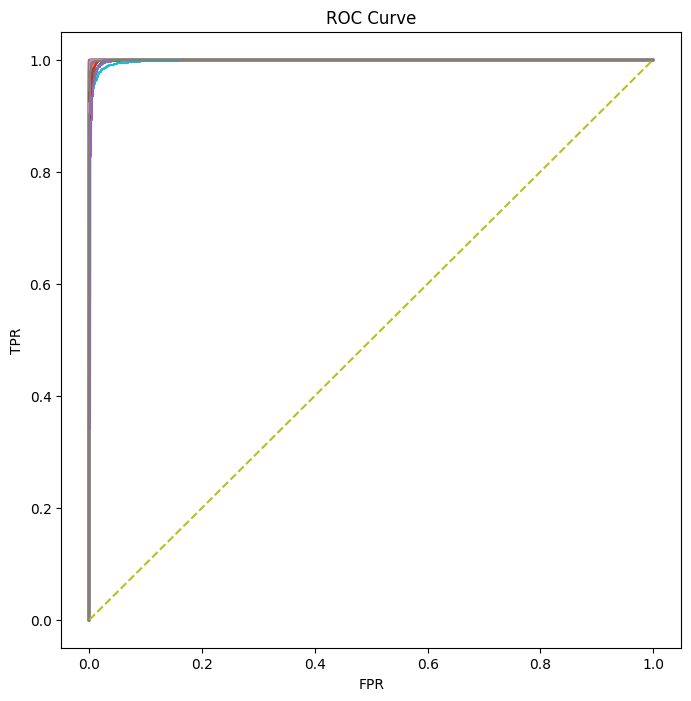

In [8]:
print("TRAINING DATA\n")
train_metrics = evaluate_model(model,train_loader,device,class_names=train_dataset.classes)

VALIDATION DATA


===== METRICS =====


Metrics,Value
Accuracy,0.969178
Precision,0.969240
Recall,0.968665
F1_Score,0.968700
ROC_AUC,0.999682
Log_loss,0.124511



============================ CONFUSION MATRIX =============================


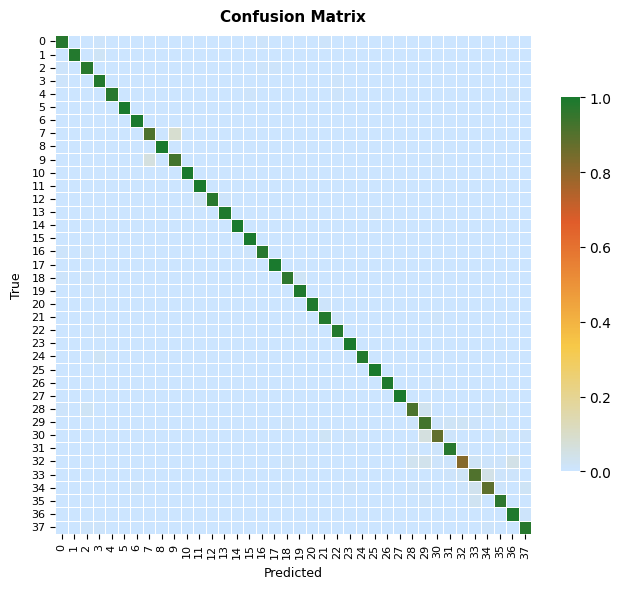


==================================== ROC CURVE ====================================


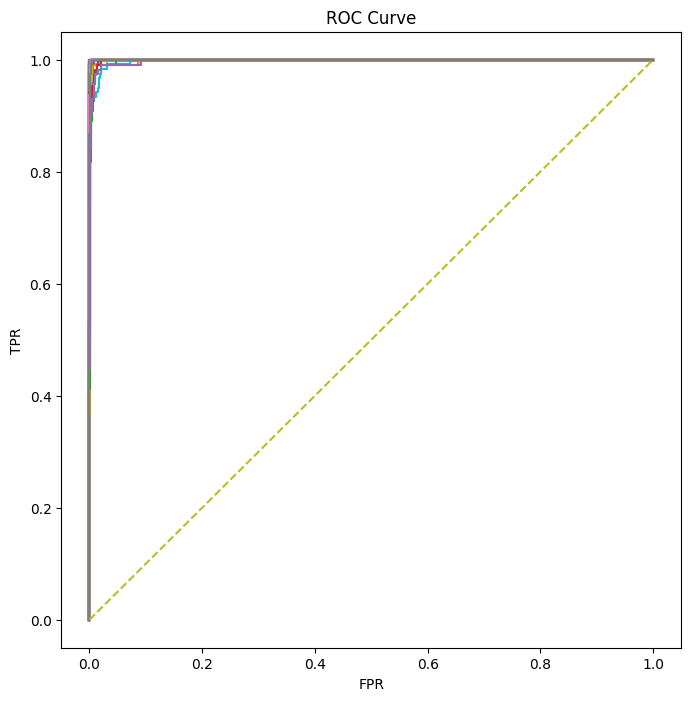

In [9]:
print("VALIDATION DATA\n")
val_metrics = evaluate_model(model,val_loader,device,class_names=train_dataset.classes)

TESTING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.971414
Precision,0.971204
Recall,0.971262
F1_Score,0.971143
ROC_AUC,0.999735
Log_loss,0.111953



============================ CONFUSION MATRIX =============================


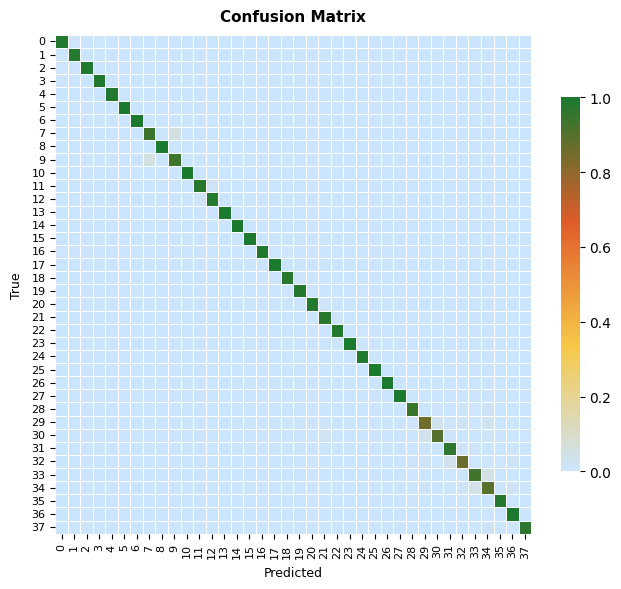


==================================== ROC CURVE ====================================


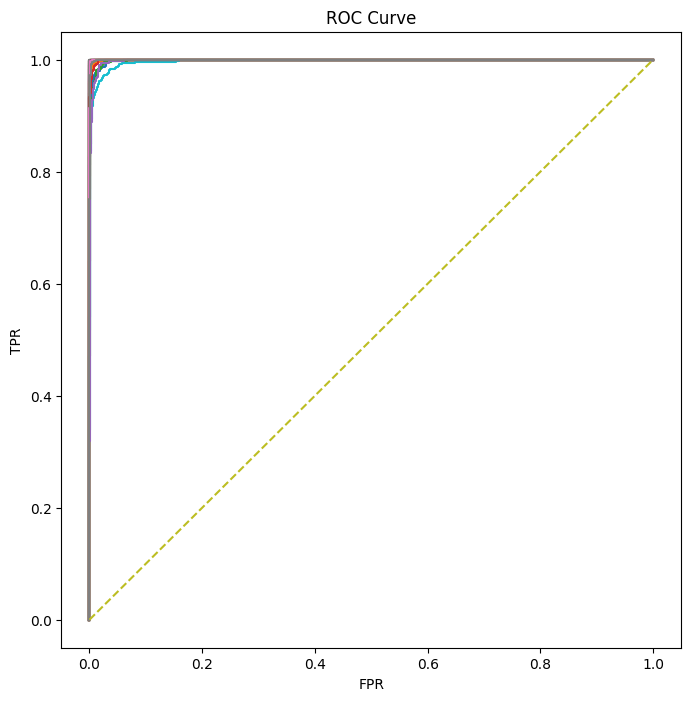

In [10]:
print("TESTING DATA\n")
test_metrics = evaluate_model(model,test_loader,device,class_names=train_dataset.classes)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9756,0.9754,0.9754,0.9753,0.9998,0.1023
val,0.9692,0.9692,0.9687,0.9687,0.9997,0.1245
test,0.9714,0.9712,0.9713,0.9711,0.9997,0.1120


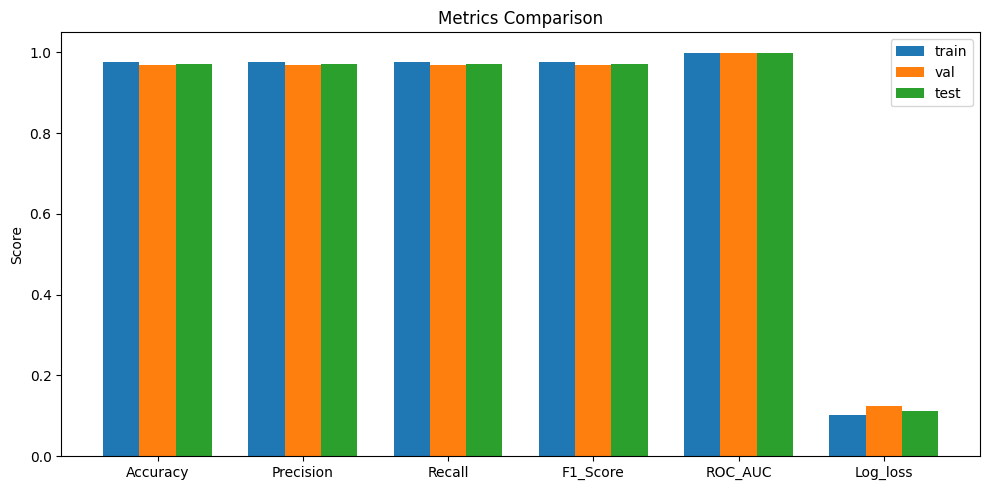

In [11]:
df_comparison=compare_splits(train_metrics,val_metrics,test_metrics)

# Feature Extraction

In [12]:
def extract_features(loader):
    model.eval()
    features = []
    preds    = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            x = model.features(images)
            x = nn.functional.relu(x)
            x = nn.functional.adaptive_avg_pool2d(x,(1,1))
            x = torch.flatten(x,1)
            out = model.classifier(x)
            prob = torch.softmax(out,1)
            features.append(x.cpu().numpy())
            preds.append(prob.cpu().numpy())

    features = np.vstack(features)
    preds    = np.vstack(preds)
    return features, preds

In [13]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=False)

train_feat, train_pred = extract_features(train_loader)
val_feat,   val_pred   = extract_features(val_loader)
test_feat,  test_pred  = extract_features(test_loader)

In [14]:
os.makedirs(FEATURE_PATH,exist_ok=True)

np.save(os.path.join(FEATURE_PATH,"dense_train_feat.npy"),train_feat)
np.save(os.path.join(FEATURE_PATH,"dense_val_feat.npy"),val_feat)
np.save(os.path.join(FEATURE_PATH,"dense_test_feat.npy"),test_feat)

np.save(os.path.join(FEATURE_PATH,"dense_train_pred.npy"),train_pred)
np.save(os.path.join(FEATURE_PATH,"dense_val_pred.npy"),val_pred)
np.save(os.path.join(FEATURE_PATH,"dense_test_pred.npy"),test_pred)